In [232]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ankitkumar342/banking-customer-churn-prediction/banking customer churn prediction.xlsx


# **bank_customer_churn_analysis**

# **Data Cleaning & Preprocessing**

In [3]:
# import libraries & packages

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Functions Used

In [234]:
# Function : Categories Sanity Check

def categorical_sanity_check(df, column, valid_values):
    invalid = df[~df[column].isin(valid_values)]
    return invalid[column].value_counts()

In [235]:
# Function : Data Type Checking

def validate_dtypes(df, expected_dtypes: dict) :
    mismatches = {}
    for col, dtype in expected_dtypes.items() :
        if col in df.columns and df[col].dtype != dtype :
            mismatches[col] = (df[col].dtype, dtype)
    return mismatches

In [236]:
# Function : Null Value Checker
def missing_value_report(df):
    return (
        df.isnull()
          .sum()
          .to_frame("missing_count")
          .assign(missing_pct = lambda x: x.missing_count / len(df))
          .query("missing_count > 0")
    )

In [237]:
# Function : Outlier Detection & Distribution
def plot_distribution(df, col):
    sns.histplot(df[col], kde = True)
    plt.title(f"Distribution of {col}")
    plt.show()

def plot_boxplot(df, col):
    sns.boxplot(x = df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

# **DEMOGRAPHIC**

In [238]:
SHEET_NAME = "Demographic"
demographic = pd.read_excel("/kaggle/input/datasets/ankitkumar342/banking-customer-churn-prediction/banking customer churn prediction.xlsx", sheet_name = SHEET_NAME)
demographic.head()

,CustomerId,Name,Gender,Age,Salary,LocationId,Churned
0,15634602,Hargrave,Female,42,101348.88,2,1
1,15647311,Hill,Female,41,112542.58,6,0
2,15619304,Onio,Female,42,113931.57,4,1
3,15701354,Boni,Female,39,93826.63,1,0
4,15737888,Mitchell,Female,43,79084.10,4,0


In [239]:
demographic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerId  10000 non-null  int64  
 1   Name        10000 non-null  object 
 2   Gender      10000 non-null  object 
 3   Age         10000 non-null  int64  
 4   Salary      10000 non-null  float64
 5   LocationId  10000 non-null  int64  
 6   Churned     10000 non-null  int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 547.0+ KB


In [240]:
demographic.nunique()

CustomerId    10000
Name           2932
Gender            2
Age              70
Salary         9999
LocationId        6
Churned           2
dtype: int64

## **I) Categories Sanity Check**

### **1) Gender Column**

In [241]:
categorical_sanity_check(demographic, "Gender", ['Male', 'Female'])

Series([], Name: count, dtype: int64)

### **2) LocationId Column**

In [242]:
categorical_sanity_check(demographic, "LocationId", [1,2,3,4,5,6])

Series([], Name: count, dtype: int64)

### **3) Churned Column**

In [243]:
categorical_sanity_check(demographic, "Churned", [0,1])

Series([], Name: count, dtype: int64)

##  **II) Data Type Checking**

In [244]:
demographic.head()

,CustomerId,Name,Gender,Age,Salary,LocationId,Churned
0,15634602,Hargrave,Female,42,101348.88,2,1
1,15647311,Hill,Female,41,112542.58,6,0
2,15619304,Onio,Female,42,113931.57,4,1
3,15701354,Boni,Female,39,93826.63,1,0
4,15737888,Mitchell,Female,43,79084.10,4,0


In [245]:
# define dictionary
expected_dtypes = {
    'Name': 'object',
    'Gender': 'object',
    'Age': 'int64',
    'Salary': 'float64',
    'LocationId': 'int64',
    'Churned': 'int64'
}

In [246]:
 validate_dtypes(demographic, expected_dtypes)

{}

## **III) Null Value Checker**

In [247]:
missing_value_report(demographic)

,missing_count,missing_pct


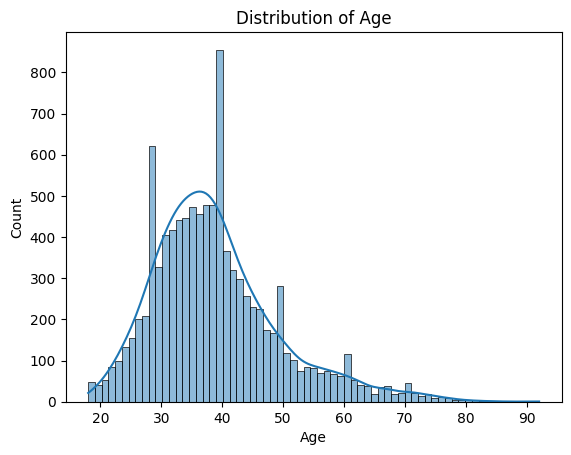

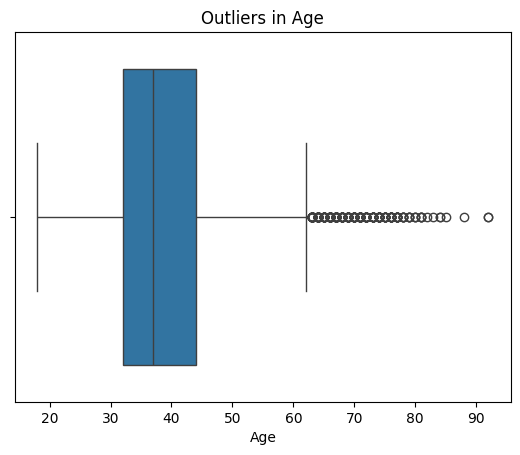

In [248]:
plot_distribution(demographic, 'Age')
plot_boxplot(demographic, 'Age')

## **IV) Remove Columns**

In [249]:
# remove name column
demographic = demographic.drop(['Name'], axis = 1)

## **V) Save The Processed Data**

In [250]:
# Save DataFrame to a CSV file
demographic.to_csv('processed_demographic_data.csv', index=False)

# **ACCOUNT**

In [251]:
SHEET_NAME = "Account"
account = pd.read_excel("/kaggle/input/datasets/ankitkumar342/banking-customer-churn-prediction/banking customer churn prediction.xlsx", sheet_name = SHEET_NAME)
account.head()

,AccountId,CustomerId,Tenure,Balance,NumProducts,HasCreditCard,IsActive
0,A15634602SID,15634602,2,NaN,1,1,1
1,A15647311SID,15647311,1,83807.86,1,0,1
2,A15619304SID,15619304,8,159660.80,3,1,0
3,A15701354SID,15701354,1,NaN,2,0,0
4,A15737888SID,15737888,2,125510.82,1,1,1


In [252]:
account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AccountId      10000 non-null  object 
 1   CustomerId     10000 non-null  int64  
 2   Tenure         10000 non-null  int64  
 3   Balance        6383 non-null   float64
 4   NumProducts    10000 non-null  int64  
 5   HasCreditCard  10000 non-null  int64  
 6   IsActive       10000 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 547.0+ KB


In [253]:
account.describe()

,CustomerId,Tenure,Balance,NumProducts,HasCreditCard,IsActive
count,1.000000e+04,10000.000000,6383.000000,10000.000000,10000.00000,10000.000000
mean,1.569094e+07,5.012800,119827.493793,1.530200,0.70550,0.515100
std,7.193619e+04,2.892174,30095.056462,0.581654,0.45584,0.499797
min,1.556570e+07,0.000000,3768.690000,1.000000,0.00000,0.000000
25%,1.562853e+07,3.000000,100181.975000,1.000000,0.00000,0.000000
50%,1.569074e+07,5.000000,119839.690000,1.000000,1.00000,1.000000
75%,1.575323e+07,7.000000,139512.290000,2.000000,1.00000,1.000000
max,1.581569e+07,10.000000,250898.090000,4.000000,1.00000,1.000000


In [254]:
account.nunique()

AccountId        10000
CustomerId       10000
Tenure              11
Balance           6381
NumProducts          4
HasCreditCard        2
IsActive             2
dtype: int64

## **I) Categories Sanity Check**

### **1) Tenure Column**

In [255]:
categorical_sanity_check(account, "Tenure", [0,1,2,3,4,5,6,7,8,9,10])

Series([], Name: count, dtype: int64)

In [256]:
account['Tenure'].unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

### **2) NumProducts Column**

In [257]:
categorical_sanity_check(account, 'NumProducts', [1,2,3,4])

Series([], Name: count, dtype: int64)

In [258]:
account['NumProducts'].unique()

array([1, 3, 2, 4])

### **3) HasCreditCard Column**

In [259]:
categorical_sanity_check(account, 'HasCreditCard', [0,1])

Series([], Name: count, dtype: int64)

### **4) IsActive Column**

In [260]:
categorical_sanity_check(account, 'IsActive', [0,1])

Series([], Name: count, dtype: int64)

## **II) DataType Checking**

In [261]:
account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AccountId      10000 non-null  object 
 1   CustomerId     10000 non-null  int64  
 2   Tenure         10000 non-null  int64  
 3   Balance        6383 non-null   float64
 4   NumProducts    10000 non-null  int64  
 5   HasCreditCard  10000 non-null  int64  
 6   IsActive       10000 non-null  int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 547.0+ KB


In [262]:
expected_dtypes1 ={
    'Tenure': 'int64',
    'Balance': 'float64',
    'NumProducts': 'int64',
    'HasCreditCard': 'int64',
    'IsActive': 'int64'
}

In [263]:
validate_dtypes(account, expected_dtypes1)

{}

## **III) Null Value Checker**

In [264]:
missing_value_report(account)

,missing_count,missing_pct
Balance,3617,0.3617


## **IV) Outlier Detection & Distribution**

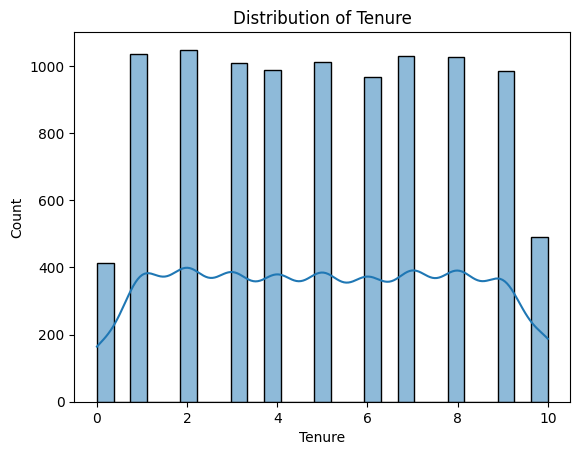

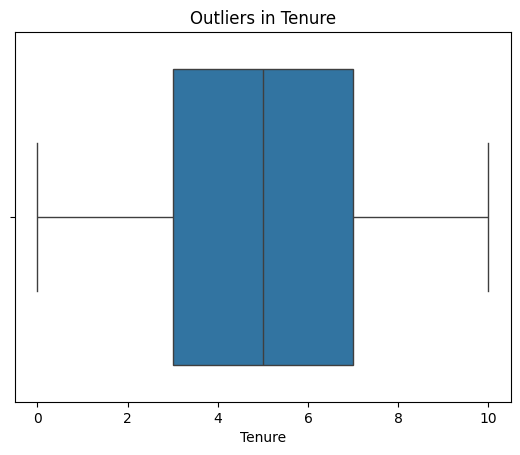

In [265]:
plot_distribution(account, 'Tenure')
plot_boxplot(account, 'Tenure')

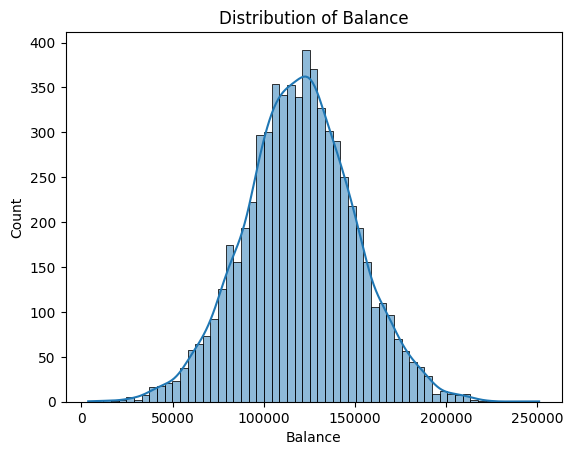

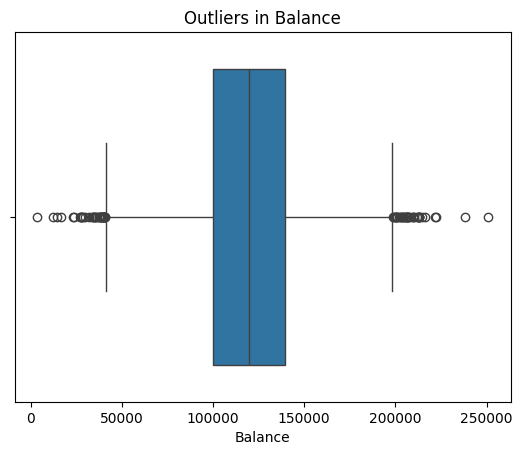

In [266]:
plot_distribution(account, 'Balance')
plot_boxplot(account, 'Balance')

## **V) Dealing With Missing Values**

In [267]:
account['Balance'].fillna(account['Balance'].mean(), inplace = True)

/tmp/ipykernel_57/952651924.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  account['Balance'].fillna(account['Balance'].mean(), inplace = True)


In [268]:
missing_value_report(account)

,missing_count,missing_pct


### **VI) Remove Columns**

In [270]:
account = account.drop(['AccountId'],axis = 1)

In [272]:
account.columns

Index(['CustomerId', 'Tenure', 'Balance', 'NumProducts', 'HasCreditCard',
       'IsActive'],
      dtype='object')

### **VII) Save The Processed Data**

In [274]:
# Save DataFrame to a CSV file
account.to_csv('processed_account_data.csv', index=False)

# **Location**

In [6]:
SHEET_NAME = "Location"
location =pd.read_excel("/kaggle/input/datasets/ankitkumar342/banking-customer-churn-prediction/banking customer churn prediction.xlsx", sheet_name = SHEET_NAME)
location.head()

,LocationId,Geography
0,1,Germany
1,2,France
2,3,Spain
3,4,UK
4,5,Canada


In [7]:
location.nunique()

LocationId    6
Geography     6
dtype: int64

In [9]:
location.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   LocationId  6 non-null      int64 
 1   Geography   6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


### **I) Save The Processed Data**

In [11]:
location.to_csv('processed_location_data.csv', index = False)